# SAR ADC — Closed-Loop ENOB Verification

**Block:** 10-bit / 10 MS/s differential SAR, 2.0 Vpp diff (LSB = 1.953 mV), targets SNDR ≥ 55 dB / ENOB ≥ 9, < 300 µW.

**Method.** The SAR *control logic* is implemented behaviorally as an ngspice `.control` reactive FSM that drives the **real** `cdac` + `comparator` subcircuits (schematic `../sar_cl_tb.sch`):

```
sample -> for bit k = 9..0:  clock comparator, read v(x), decide bit (X>1.65 => 1),
          alter CDAC switches per SAR rule, resume
```

This notebook (Python) is the **orchestrator**: it feeds a coherent sine one conversion at a time, collects the output codes, and does an FFT to extract SNDR / SFDR / ENOB.

> **Tooling note.** In-process ngspice (PySpice / ngspyce shared mode) *segfaults* in this container, so we drive the **ngspice-46 CLI** in batch. The reactive loop lives inside the netlist's `.control` block; Python only sets the per-conversion input and parses the printed code.

SAR rule (verified): `bit=1 -> dnP[c]+upN[c]` (lower vdiff); `bit=0 -> upP[c]+dnN[c]`; cap index `c = k-1`, MSB free.

In [1]:
import subprocess, re, os, tempfile, pathlib, time
import numpy as np
import matplotlib.pyplot as plt

NG     = '/foss/tools/ngspice/bin/ngspice'
XSCHEM = '/foss/tools/xschem/bin/xschem'
TB     = pathlib.Path('..').resolve()          # .../saradc/tb
SCH    = TB/'sar_cl_tb.sch'
SIM    = TB/'simulation'; SIM.mkdir(exist_ok=True)
VDD, VTH = 3.3, 1.65                            # comparator decision threshold
NBITS, FS = 10, 10e6
VREF = 1.0                                      # vrefp-vrefn -> FS = 2*VREF Vpp diff
LSB  = 2*VREF/2**NBITS                          # 1.953 mV
print(f'LSB = {LSB*1e3:.4f} mV')

LSB = 1.9531 mV


## 1. Netlist the schematic (single source of truth)
Re-run this whenever you edit `sar_cl_tb.sch` in xschem.

In [2]:
r = subprocess.run([XSCHEM,'-n','-q','-b','--rcfile',str(TB/'xschemrc'),
                    str(SCH),'-o',str(SIM)], capture_output=True, text=True)
BASE = (SIM/'sar_cl_tb.spice').read_text()
assert '.control' in BASE and 'RESULT_CODE_BELOW' in BASE, 'netlist missing FSM'
print('netlisted', SCH.name, '->', BASE.count(chr(10)), 'lines')

netlisted sar_cl_tb.sch -> 360 lines


## 2. Single-conversion driver
We model one conversion as a held DC differential input `vid = vinp - vinn`. The input is set at the *bin center* of the target code so tight bits don't sit on a decision edge:

$$vid = (code-512)\cdot LSB + LSB/2$$

`run_conversion(vid)` patches `.param vid` in the netlist, runs ngspice, and parses the printed `code`.

In [3]:
def vid_for_code(code):
    return (code-512)*LSB + LSB/2

def run_conversion(vid):
    net = re.sub(r'\.param vid = [-0-9.eE]+', f'.param vid = {vid:.8g}', BASE)
    fd, p = tempfile.mkstemp(suffix='.spice', dir=str(SIM)); os.write(fd, net.encode()); os.close(fd)
    try:
        out = subprocess.run([NG,'-b',p], capture_output=True, text=True).stdout
    finally:
        os.unlink(p)
    m = re.search(r'code = ([0-9.eE+\-]+)', out)
    if not m: raise RuntimeError('no code parsed:\n'+out[-500:])
    return int(round(float(m.group(1))))

### Sanity: reproduce the two known open-loop codes

In [4]:
for code in (992, 682):
    got = run_conversion(vid_for_code(code))
    print(f'target {code:4d}  ->  got {got:4d}   {"OK" if got==code else "MISMATCH"}')

target  992  ->  got  992   OK


target  682  ->  got  682   OK


## 3. Coherent sampling for the FFT

An N-point DFT implicitly assumes the N samples are **one period** of a periodic signal — it treats the record as repeating forever. Two consequences drive our choice of input frequency:

**Why `fin = (Mcoh / N) * fs` with `Mcoh` an integer.**
If the input sine does *not* complete a whole number of cycles in the N samples, the record's end doesn't connect smoothly to its start. That seam discontinuity smears the tone's energy across **all** bins (*spectral leakage*), raising the apparent noise floor and wrecking SNDR/ENOB. Forcing an integer number of cycles `Mcoh` in N samples makes the sine close on itself, so all its energy lands in exactly one bin (bin `Mcoh`) with zero leakage — no window needed. Hence `fin/fs = Mcoh/N`.

**Why `Mcoh` is chosen prime / coprime to N.**
The sampled phase sequence is `phi_k = 2*pi*Mcoh*k/N`. The number of *distinct* phase points it visits (hence distinct input amplitudes, hence distinct codes exercised) equals `N / gcd(Mcoh, N)`. If `gcd(Mcoh,N) = g > 1`, only `N/g` distinct levels are tested and each is hit `g` times — poor coverage of the transfer curve. With `gcd(Mcoh,N)=1` (coprime) all N samples hit distinct phases → **maximal code coverage**. A second benefit: the j-th harmonic folds to bin `(j*Mcoh) mod N`; when `Mcoh` is coprime to N, no harmonic ever lands back on the fundamental or DC, so distortion stays on clean, separate bins where the SFDR calc can see it. Since N here is a power of 2, any odd `Mcoh` is coprime — picking a **prime** guarantees it. (We use N=64, Mcoh=7.)

FFT processing gain ≈ `10*log10(N/2)`; a larger N lowers the noise floor so the true ENOB shows. Start at N=64 for a quick check; bump to 256/512/1024 for a cleaner floor (≈2.3 s/conversion here).

In [5]:
N    = 64        # number of conversions (FFT length); power of 2
Mcoh = 7         # input cycles in the record: prime, coprime to N
A    = 0.95      # sine amplitude in vid volts (full scale = +/- VREF) -> ~-0.4 dBFS
fin  = Mcoh/N*FS
print(f'fin = {fin/1e6:.4f} MHz   ({Mcoh} cycles / {N} samples @ {FS/1e6:.0f} MS/s)')

k   = np.arange(N)
vid_seq = A*VREF*np.sin(2*np.pi*Mcoh*k/N)

fin = 1.0938 MHz   (7 cycles / 64 samples @ 10 MS/s)


In [6]:
t0 = time.time()
codes = np.array([run_conversion(v) for v in vid_seq], float)
print(f'swept {N} conversions in {time.time()-t0:.1f}s   |   code range {codes.min():.0f}..{codes.max():.0f}')

swept 64 conversions in 144.9s   |   code range 25..998


## 4. Spectrum -> SNDR / SFDR / ENOB

In [7]:
x = codes - codes.mean()                 # remove DC
P = np.abs(np.fft.rfft(x))**2            # coherent -> no window
P[0] = 0.0
sig  = Mcoh                              # signal bin
Psig = P[sig]
Pnd  = P.sum() - Psig                    # noise + distortion
SNDR = 10*np.log10(Psig/Pnd)
ENOB = (SNDR-1.76)/6.02
spur = P.copy(); spur[sig] = 0
SFDR = 10*np.log10(Psig/spur.max())
print(f'SNDR = {SNDR:5.1f} dB     ENOB = {ENOB:4.2f} bits     SFDR = {SFDR:5.1f} dB')
print(f'spec: SNDR >= 55 dB, ENOB >= 9  ->  {"PASS" if (SNDR>=55 and ENOB>=9) else "FAIL"}')

SNDR =  60.5 dB     ENOB = 9.75 bits     SFDR =  65.1 dB
spec: SNDR >= 55 dB, ENOB >= 9  ->  PASS


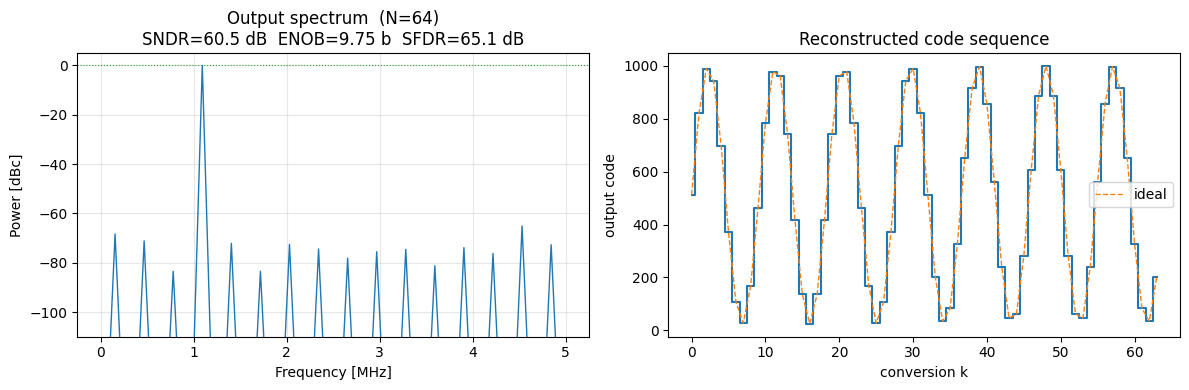

In [8]:
fig, ax = plt.subplots(1, 2, figsize=(12,4))
PdB = 10*np.log10(P/Psig + 1e-20)        # dBc
f   = np.arange(len(P))/N*FS/1e6
ax[0].plot(f, PdB, lw=1)
ax[0].axhline(0, color='C2', ls=':', lw=0.8)
ax[0].set(xlabel='Frequency [MHz]', ylabel='Power [dBc]', ylim=(-110,5),
          title=f'Output spectrum  (N={N})\nSNDR={SNDR:.1f} dB  ENOB={ENOB:.2f} b  SFDR={SFDR:.1f} dB')
ax[0].grid(alpha=0.3)
ax[1].step(k, codes, where='mid'); ax[1].plot(k, 512+vid_seq/LSB, 'C1--', lw=1, label='ideal')
ax[1].set(xlabel='conversion k', ylabel='output code', title='Reconstructed code sequence'); ax[1].legend()
plt.tight_layout(); plt.show()

## Notes / next steps
- This is **nominal** ENOB: ngspice `.tran` has no device noise, so the comparator-noise budget is handled analytically (see `comp_sizing.ipynb`).
- Speed: each conversion is one ngspice launch. For large N, batch many conversions in one `.control` run (PDK parsed once).
- Then: (2) re-check regeneration speed with the real extracted Cpq, (3) resize Cu, (4) bootstrapped sampling switch, (5) DNL/INL Monte-Carlo (`sw_stat_global=1`).